# Track Boundary Detection — Strip Pipeline

**Pipeline**: Resize → Strip (30/20/50) → Stretch middle → Baseline evaluation → Fine-tune → Analysis

| Step | Operation | Detail |
|------|-----------|--------|
| 1 | **Resize** | 1280×720 → 256×128 (model input) |
| 2 | **Strip 30/20/50** | Top 30% sky removed, **middle 20% kept**, bottom 50% car/chassis removed |
| 3 | **Stretch** | Middle strip (144px tall) → full 128×256 resolution |
| 4 | **Baseline** | Load `unet_road_curb_best.keras` (7.8M params), evaluate on strip data |
| 5 | **Fine-tune** | Retrain on strip-space images, compare with baseline |
| 6 | **Analyze** | Boundary extraction, error maps, quality buckets |

**Baseline model**: `models/unet_road_curb_best.keras` (128×256 input, trained on full-frame data)


## 0. Setup & Configuration


In [6]:
import os, gc, time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import directed_hausdorff

np.random.seed(42)
tf.random.set_seed(42)

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ── Paths ──
CAMERAS        = ['camera_fl', 'camera_fr']
IMG_DIR        = "dataset/images"           # 1280×720 originals
STRIP_IMG_DIR  = "dataset/images_strip"     # stripped+stretched images

# ── Model config ──
IMG_H, IMG_W = 128, 256                     # model input resolution
BATCH_SIZE   = 8
BASELINE_PATH = "models/unet_road_curb_best.keras"
FINETUNE_PATH = "models/unet_strip_finetuned.keras"

# ── Strip config: 50% top / 20% middle / 30% bottom ──
STRIP_TOP = 0.50   # remove top 50%  (sky, horizon)
STRIP_BOT = 0.30   # remove bottom 30% (car nose, chassis)
STRIP_MID = 1.0 - STRIP_TOP - STRIP_BOT  # keep middle 20%

# Pixel rows on 720px image
H_ORIG, W_ORIG = 720, 1280
Y_START = int(H_ORIG * STRIP_TOP)         # row 360
Y_END   = int(H_ORIG * (1 - STRIP_BOT))   # row 504
STRIP_H = Y_END - Y_START                  # 144 px

print(f"TF {tf.__version__} | GPU: {len(gpus)}")
print(f"Strip: top {STRIP_TOP*100:.0f}% / mid {STRIP_MID*100:.0f}% / bot {STRIP_BOT*100:.0f}%")
print(f"  → rows [{Y_START}:{Y_END}] = {STRIP_H}px of {H_ORIG}px")
print(f"  → stretched to {IMG_W}×{IMG_H}")
print(f"Baseline model: {BASELINE_PATH}")


TF 2.21.0 | GPU: 1
Strip: top 50% / mid 20% / bot 30%
  → rows [360:503] = 143px of 720px
  → stretched to 256×128
Baseline model: models/unet_road_curb_best.keras


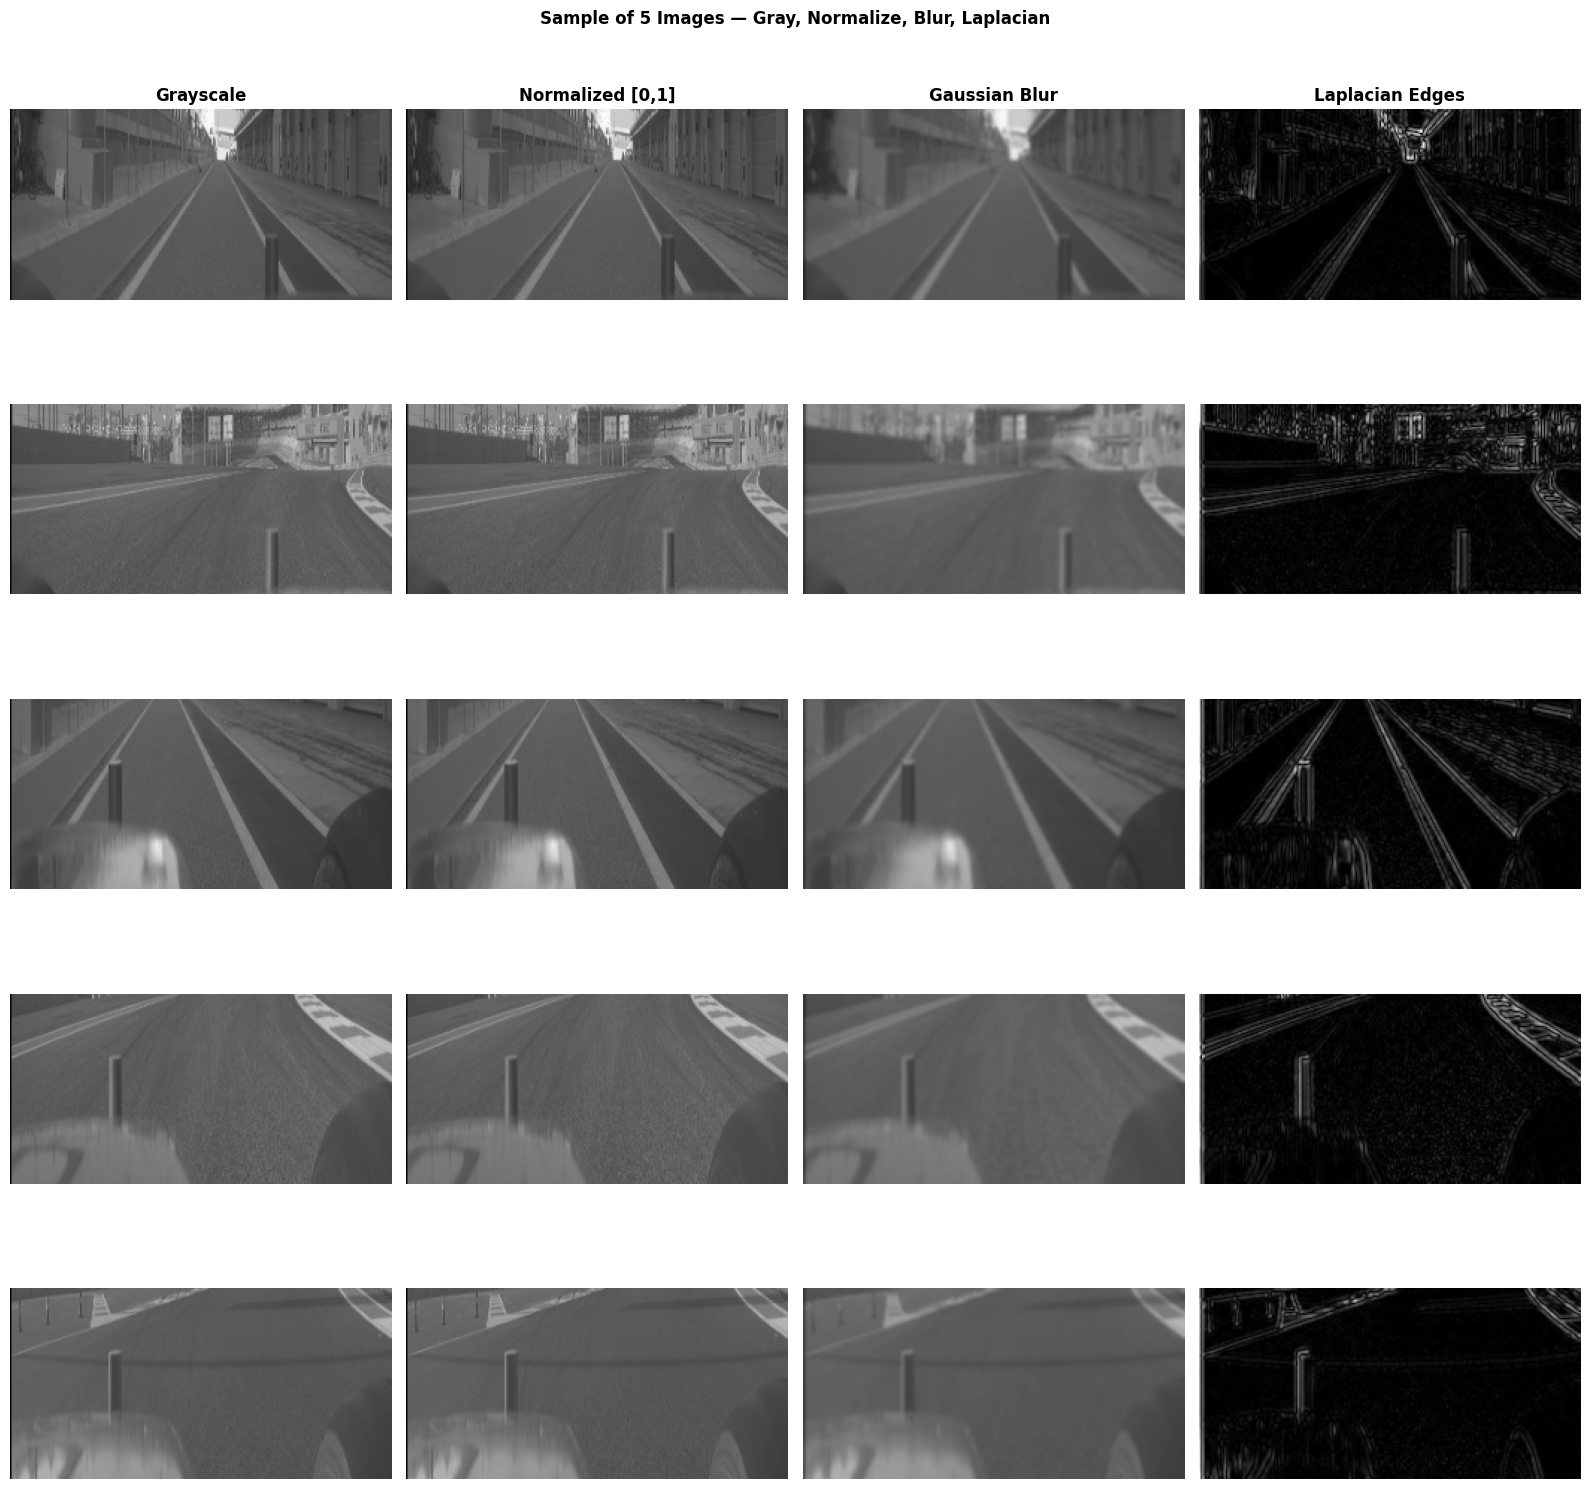

In [8]:
# Show 5 sample preprocessed images with classic CV stages:
# grayscale -> normalize [0,1] -> gaussian blur -> laplacian edges
sample_paths = []
for cam_id in CAMERAS:
    cam_dir = os.path.join(STRIP_IMG_DIR, cam_id)
    if not os.path.isdir(cam_dir):
        continue
    files = sorted([f for f in os.listdir(cam_dir) if f.endswith('.jpg')])
    sample_paths.extend([(cam_id, os.path.join(cam_dir, f), f) for f in files])

if len(sample_paths) == 0:
    raise FileNotFoundError(f"No preprocessed images found in: {STRIP_IMG_DIR}")

n_show = min(5, len(sample_paths))
idxs = np.linspace(0, len(sample_paths) - 1, n_show, dtype=int)
chosen = [sample_paths[i] for i in idxs]

fig, axes = plt.subplots(n_show, 4, figsize=(16, 3.2 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

col_titles = ["Grayscale", "Normalized [0,1]", "Gaussian Blur", "Laplacian Edges"]
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontweight='bold')

for row, (cam_id, img_path, fname) in enumerate(chosen):
    img_bgr = cv2.imread(img_path)
    gray_u8 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_norm = gray_u8.astype(np.float32) / 255.0
    blur = cv2.GaussianBlur(gray_norm, (5, 5), 0)
    lap = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
    lap_vis = cv2.normalize(np.abs(lap), None, 0.0, 1.0, cv2.NORM_MINMAX)

    axes[row, 0].imshow(gray_u8, cmap='gray', vmin=0, vmax=255)
    axes[row, 1].imshow(gray_norm, cmap='gray', vmin=0.0, vmax=1.0)
    axes[row, 2].imshow(blur, cmap='gray', vmin=0.0, vmax=1.0)
    axes[row, 3].imshow(lap_vis, cmap='gray', vmin=0.0, vmax=1.0)

    axes[row, 0].set_ylabel(f"{cam_id}\n{fname}", fontsize=8)
    for col in range(4):
        axes[row, col].axis('off')

plt.suptitle("Sample of 5 Images — Gray, Normalize, Blur, Laplacian", fontweight='bold')
plt.tight_layout()
plt.show()

## 1. Baseline Model — Road Edge Detection

Train a lightweight segmentation baseline on strip images using **auto-generated edge pseudo-labels**:
- Pseudo-labels: grayscale → Gaussian blur → Canny edges + lower-road ROI
- Model: small U-Net style encoder-decoder
- Loss: binary cross-entropy
- Metric: IoU + Dice

This provides a fast baseline before moving to stronger supervised models.

In [9]:
# Build training data from strip images + edge pseudo-labels
EDGE_MODEL_PATH = "models/road_edge_baseline.keras"
MAX_SAMPLES = 2000
VAL_SPLIT = 0.20

def build_edge_pseudolabel(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 60, 160)

    h, w = edges.shape
    roi = np.zeros((h, w), dtype=np.uint8)
    roi[int(h * 0.35):, :] = 255
    edges = cv2.bitwise_and(edges, roi)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.dilate(edges, kernel, iterations=1)
    return (edges > 0).astype(np.float32)

# Collect strip image paths
img_paths = []
for cam_id in CAMERAS:
    cam_dir = os.path.join(STRIP_IMG_DIR, cam_id)
    if not os.path.isdir(cam_dir):
        continue
    files = sorted([f for f in os.listdir(cam_dir) if f.endswith('.jpg')])
    img_paths.extend([os.path.join(cam_dir, f) for f in files])

if len(img_paths) == 0:
    raise FileNotFoundError(f"No strip images found in: {STRIP_IMG_DIR}")

if len(img_paths) > MAX_SAMPLES:
    idxs = np.linspace(0, len(img_paths) - 1, MAX_SAMPLES, dtype=int)
    img_paths = [img_paths[i] for i in idxs]

n = len(img_paths)
X = np.zeros((n, IMG_H, IMG_W, 3), dtype=np.float32)
Y = np.zeros((n, IMG_H, IMG_W, 1), dtype=np.float32)

for i, p in enumerate(img_paths):
    img_bgr = cv2.imread(p)
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    X[i] = img_rgb.astype(np.float32) / 255.0
    Y[i, :, :, 0] = build_edge_pseudolabel(img_bgr)

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=VAL_SPLIT, random_state=42
 )

print(f"Loaded {n} samples | Train: {len(X_train)} | Val: {len(X_val)}")
print(f"Edge coverage (train): {Y_train.mean() * 100:.2f}%")
print(f"Edge coverage (val):   {Y_val.mean() * 100:.2f}%")

Loaded 2000 samples | Train: 1600 | Val: 400
Edge coverage (train): 3.40%
Edge coverage (val):   3.35%


In [10]:
# Baseline road-edge model (small U-Net style)
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def build_edge_baseline(input_shape=(IMG_H, IMG_W, 3)):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPool2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPool2D()(c2)

    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(b)

    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)
    return Model(inputs, outputs, name='road_edge_baseline')

tf.keras.backend.clear_session()
edge_model = build_edge_baseline()
edge_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[dice_coefficient, iou_metric],
)
edge_model.summary()

callbacks = [
    ModelCheckpoint(EDGE_MODEL_PATH, monitor='val_iou_metric', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_iou_metric', mode='max', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

history = edge_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=12,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
 )

edge_model = tf.keras.models.load_model(
    EDGE_MODEL_PATH,
    custom_objects={'dice_coefficient': dice_coefficient, 'iou_metric': iou_metric},
)
print(f"Saved baseline model: {EDGE_MODEL_PATH}")

I0000 00:00:1773166798.081246    4679 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6631 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "road_edge_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 128,   │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 128,   │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 128,   │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 128,   │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 128,   │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 128,   │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 128,   │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 256,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 256,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,273 (462.00 KB)

 Trainable params: 118,273 (462.00 KB)

...

Epoch 1/12


I0000 00:00:1773166802.244973   10864 service.cc:153] XLA service 0x7a7b70006e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773166802.244993   10864 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 with Max-Q Design, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1773166802.326752   10864 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773166802.864965   10864 cuda_dnn.cc:461] Loaded cuDNN version 91900
E0000 00:00:1773166804.467751   10864 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773166804.981641   10864 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Sys

  5/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - dice_coefficient: 0.0718 - iou_metric: 0.0211 - loss: 0.6885

I0000 00:00:1773166810.623416   10864 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - dice_coefficient: 0.0820 - iou_metric: 0.0064 - loss: 0.2482
Epoch 1: val_iou_metric improved from None to 0.17193, saving model to models/road_edge_baseline.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - dice_coefficient: 0.1526 - iou_metric: 0.0420 - loss: 0.1461 - val_dice_coefficient: 0.2969 - val_iou_metric: 0.1719 - val_loss: 0.0773 - learning_rate: 0.0010
Epoch 2/12
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - dice_coefficient: 0.3465 - iou_metric: 0.2361 - loss: 0.0753
Epoch 2: val_iou_metric improved from 0.17193 to 0.33252, saving model to models/road_edge_baseline.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - dice_coefficient: 0.3857 - iou_metric: 0.2903 - loss: 0.0689 - val_dice_coefficient: 0.3937 - val_iou_metric: 0.3325 - val_loss: 0.0634 - learning_rate: 0.0010
Epoch 3/12
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - dice_coefficient: 0.4352 - iou_metric: 0.3531 - loss: 0.0628
Epoch 3: val_iou_metric improved from 0.33252

Validation IoU: 0.4776 ± 0.2144


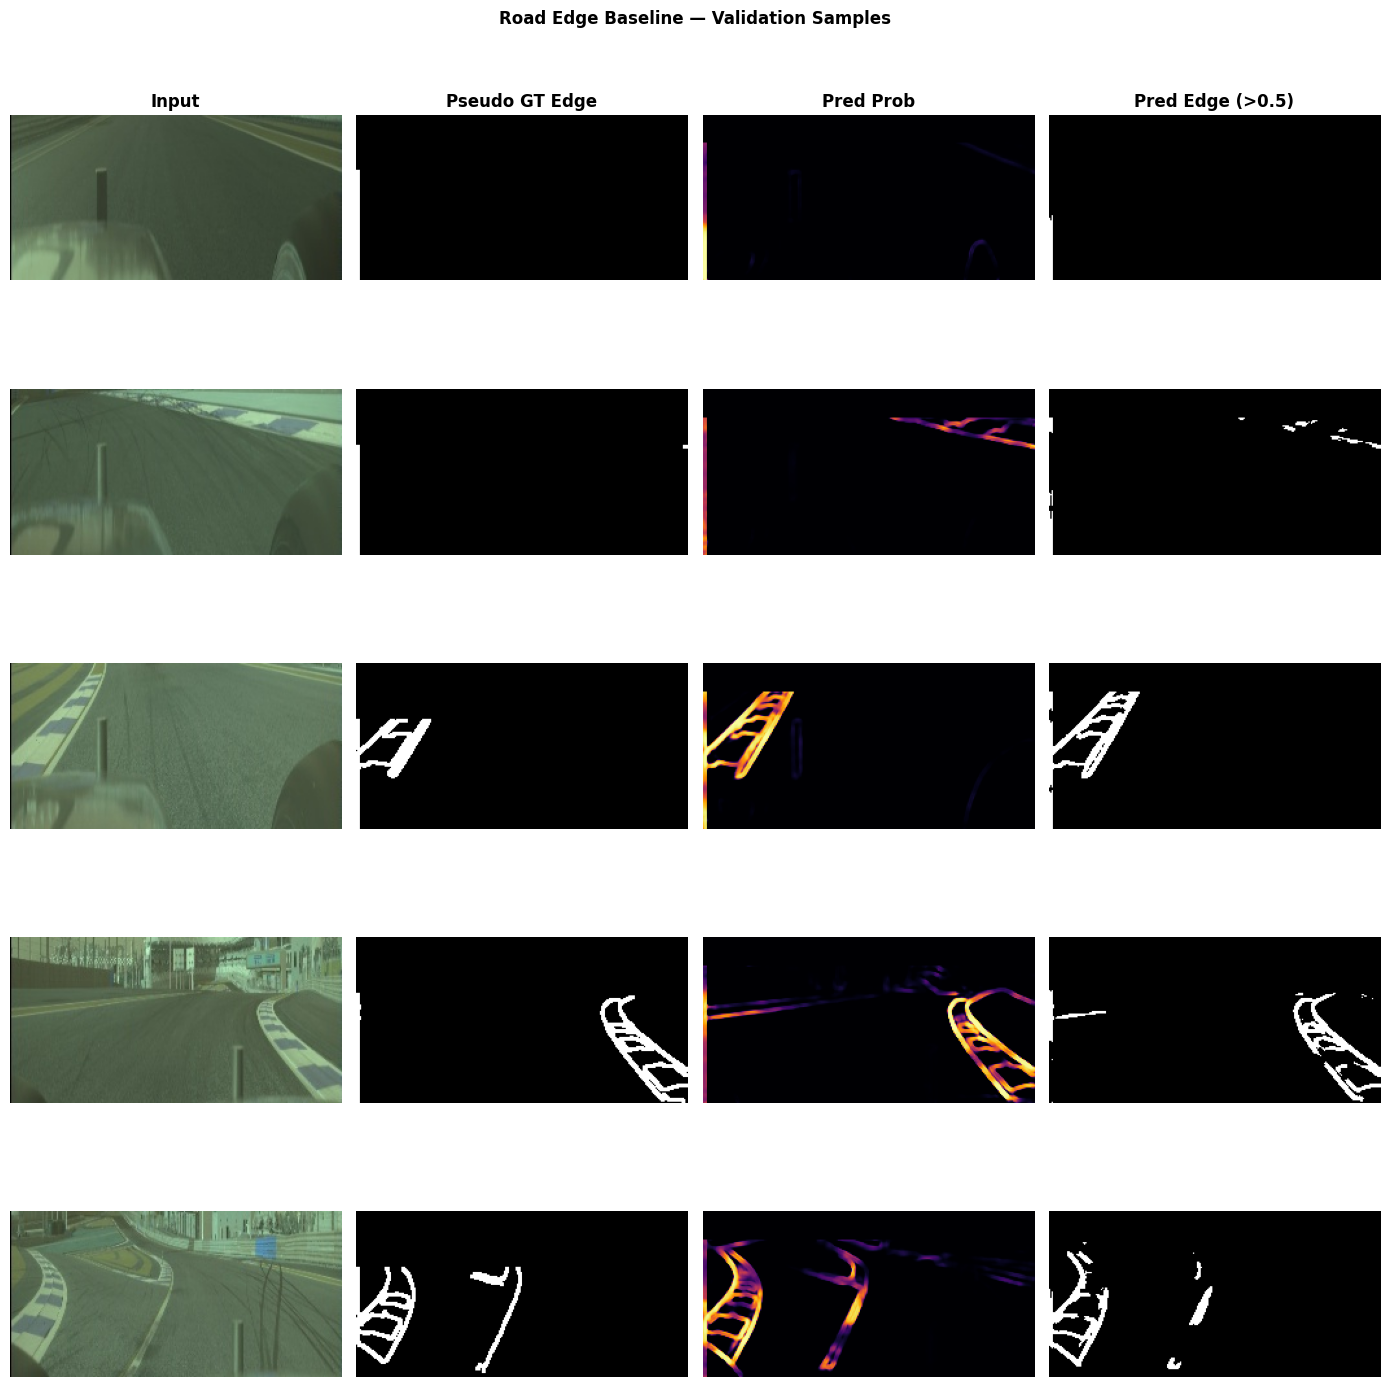

In [11]:
# Baseline evaluation + qualitative results
pred_val = edge_model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
pred_bin = (pred_val > 0.5).astype(np.float32)

intersection = np.sum(Y_val * pred_bin, axis=(1, 2, 3))
union = np.sum(Y_val, axis=(1, 2, 3)) + np.sum(pred_bin, axis=(1, 2, 3)) - intersection
iou_scores = (intersection + 1e-6) / (union + 1e-6)
print(f"Validation IoU: {iou_scores.mean():.4f} ± {iou_scores.std():.4f}")

n_show = min(5, len(X_val))
idxs = np.linspace(0, len(X_val) - 1, n_show, dtype=int)
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

titles = ["Input", "Pseudo GT Edge", "Pred Prob", "Pred Edge (>0.5)"]
for c, t in enumerate(titles):
    axes[0, c].set_title(t, fontweight='bold')

for r, idx in enumerate(idxs):
    axes[r, 0].imshow(X_val[idx])
    axes[r, 1].imshow(Y_val[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[r, 2].imshow(pred_val[idx, :, :, 0], cmap='inferno', vmin=0, vmax=1)
    axes[r, 3].imshow(pred_bin[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[r, 0].set_ylabel(f"IoU={iou_scores[idx]:.2f}", rotation=0, labelpad=35, fontsize=9, va='center')
    for c in range(4):
        axes[r, c].axis('off')

plt.suptitle("Road Edge Baseline — Validation Samples", fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Next Step — Segment Runnable Road

Convert edge predictions into **drivable road-area pseudo-labels**, then train a road-surface segmentation baseline.

Approach:
- Predict edge probability maps with the edge baseline
- Convert edges to barriers and flood-fill from bottom-center seed
- Train a second lightweight U-Net on road-area masks

In [12]:
# Build runnable-road pseudo-labels from edge model predictions
ROAD_MODEL_PATH = "models/runnable_road_baseline.keras"
ROAD_EDGE_THRESH = 0.35
ROAD_MAX_SAMPLES = 2000

def edge_to_runnable_road(edge_prob, edge_thresh=ROAD_EDGE_THRESH):
    h, w = edge_prob.shape
    edge_bin = (edge_prob > edge_thresh).astype(np.uint8) * 255
    edge_bin = cv2.dilate(edge_bin, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=1)

    # Keep only lower-road ROI
    roi = np.zeros((h, w), dtype=np.uint8)
    roi[int(h * 0.35):, :] = 255
    barrier = cv2.bitwise_and(edge_bin, roi)

    # Flood-fill free-space from bottom-center
    free = cv2.bitwise_not(barrier)
    ff = free.copy()
    ff_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    seed = (w // 2, h - 2)
    cv2.floodFill(ff, ff_mask, seedPoint=seed, newVal=128)
    road = (ff == 128).astype(np.uint8)

    # Clean mask
    road = cv2.morphologyEx(road, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1)
    road = cv2.morphologyEx(road, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=1)
    return road.astype(np.float32)

# Use existing X if available; otherwise rebuild quickly from strip images
if 'X' not in globals() or X is None or len(X) == 0:
    img_paths = []
    for cam_id in CAMERAS:
        cam_dir = os.path.join(STRIP_IMG_DIR, cam_id)
        if not os.path.isdir(cam_dir):
            continue
        files = sorted([f for f in os.listdir(cam_dir) if f.endswith('.jpg')])
        img_paths.extend([os.path.join(cam_dir, f) for f in files])

    if len(img_paths) == 0:
        raise FileNotFoundError(f"No strip images found in: {STRIP_IMG_DIR}")

    if len(img_paths) > ROAD_MAX_SAMPLES:
        idxs = np.linspace(0, len(img_paths) - 1, ROAD_MAX_SAMPLES, dtype=int)
        img_paths = [img_paths[i] for i in idxs]

    X = np.zeros((len(img_paths), IMG_H, IMG_W, 3), dtype=np.float32)
    for i, p in enumerate(img_paths):
        img_bgr = cv2.imread(p)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        X[i] = img_rgb.astype(np.float32) / 255.0

# Ensure edge model is available
if 'edge_model' not in globals() or edge_model is None:
    edge_model = tf.keras.models.load_model(
        EDGE_MODEL_PATH,
        custom_objects={'dice_coefficient': dice_coefficient, 'iou_metric': iou_metric},
    )

edge_prob_all = edge_model.predict(X, batch_size=BATCH_SIZE, verbose=0)
Y_road = np.zeros((len(X), IMG_H, IMG_W, 1), dtype=np.float32)
for i in range(len(X)):
    Y_road[i, :, :, 0] = edge_to_runnable_road(edge_prob_all[i, :, :, 0])

Xr_train, Xr_val, Yr_train, Yr_val = train_test_split(
    X, Y_road, test_size=0.20, random_state=42
 )

print(f"Road pseudo-labels: total {len(X)} | train {len(Xr_train)} | val {len(Xr_val)}")
print(f"Road coverage (train): {Yr_train.mean() * 100:.2f}%")
print(f"Road coverage (val):   {Yr_val.mean() * 100:.2f}%")

Road pseudo-labels: total 2000 | train 1600 | val 400
Road coverage (train): 94.31%
Road coverage (val):   94.56%


In [13]:
# Train runnable-road segmentation baseline
def build_road_baseline(input_shape=(IMG_H, IMG_W, 3)):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(24, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(24, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPool2D()(c1)

    c2 = layers.Conv2D(48, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(48, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPool2D()(c2)

    b = layers.Conv2D(96, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(96, 3, activation='relu', padding='same')(b)

    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(48, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(48, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(24, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(24, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)
    return Model(inputs, outputs, name='runnable_road_baseline')

tf.keras.backend.clear_session()
road_model = build_road_baseline()
road_model.compile(
    optimizer=keras.optimizers.Adam(8e-4),
    loss='binary_crossentropy',
    metrics=[dice_coefficient, iou_metric],
)
road_model.summary()

road_callbacks = [
    ModelCheckpoint(ROAD_MODEL_PATH, monitor='val_iou_metric', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_iou_metric', mode='max', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

road_history = road_model.fit(
    Xr_train, Yr_train,
    validation_data=(Xr_val, Yr_val),
    epochs=12,
    batch_size=BATCH_SIZE,
    callbacks=road_callbacks,
    verbose=1,
 )

road_model = tf.keras.models.load_model(
    ROAD_MODEL_PATH,
    custom_objects={'dice_coefficient': dice_coefficient, 'iou_metric': iou_metric},
)
print(f"Saved runnable-road model: {ROAD_MODEL_PATH}")

Model: "runnable_road_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 256,  │        672 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 256,  │      5,208 │ conv2d[0][0]      │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 128,   │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 128,   │     10,416 │ max_pooling2d[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 128,   │     20,784 │ conv2d_2[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 64,    │     41,568 │ max_pooling2d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 64,    │     83,040 │ conv2d_4[0][0]    │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 128,   │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 128,   │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 144)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 128,   │     62,256 │ concatenate[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 128,   │     20,784 │ conv2d_6[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 72)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 256,  │     15,576 │ concatenate_1[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 256,  │      5,208 │ conv2d_8[0][0]  

 Total params: 265,537 (1.01 MB)

 Trainable params: 265,537 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12


E0000 00:00:1773167066.128910   10863 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773167067.159143   10863 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773167068.220027   10863 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
W0000 00:00:1773167068.672556   10863 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch siz

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - dice_coefficient: 0.8982 - iou_metric: 0.9126 - loss: 0.3065

W0000 00:00:1773167092.441959   10867 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.97GiB (rounded to 4261137920)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1773167092.449377   10867 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1773167092.449391   10867 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 188, Chunks in use: 187. 47.0KiB allocated for chunks. 46.8KiB in use in bin. 11.9KiB client-requested in use in bin.
I0000 00:00:1773167092.449405   10867 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 6, Chunks in use: 6. 3.0KiB allocated for chunks. 3.0KiB in use in bin. 2.2KiB client-requested in use in bin.
I0000 00:00:1773167092.449407   10867 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 9, Chunks in use: 7. 14.2KiB allocated for 


Epoch 1: val_iou_metric improved from None to 0.94976, saving model to models/runnable_road_baseline.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - dice_coefficient: 0.9339 - iou_metric: 0.9373 - loss: 0.2197 - val_dice_coefficient: 0.9595 - val_iou_metric: 0.9498 - val_loss: 0.1333 - learning_rate: 8.0000e-04
Epoch 2/12
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - dice_coefficient: 0.9517 - iou_metric: 0.9417 - loss: 0.1689
Epoch 2: val_iou_metric improved from 0.94976 to 0.95401, saving model to models/runnable_road_baseline.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - dice_coefficient: 0.9576 - iou_metric: 0.9475 - loss: 0.1433 - val_dice_coefficient: 0.9615 - val_iou_metric: 0.9540 - val_loss: 0.1186 - learning_rate: 8.0000e-04
Epoch 3/12
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - dice_coefficient: 0.9566 - iou_metric: 0.9453 - loss: 0.1524
Epoch 3: val_iou_metric did not improve from 0.95401
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - dice_coefficient: 0.9608 - iou_metr

Runnable-road IoU: 0.9732 ± 0.0523


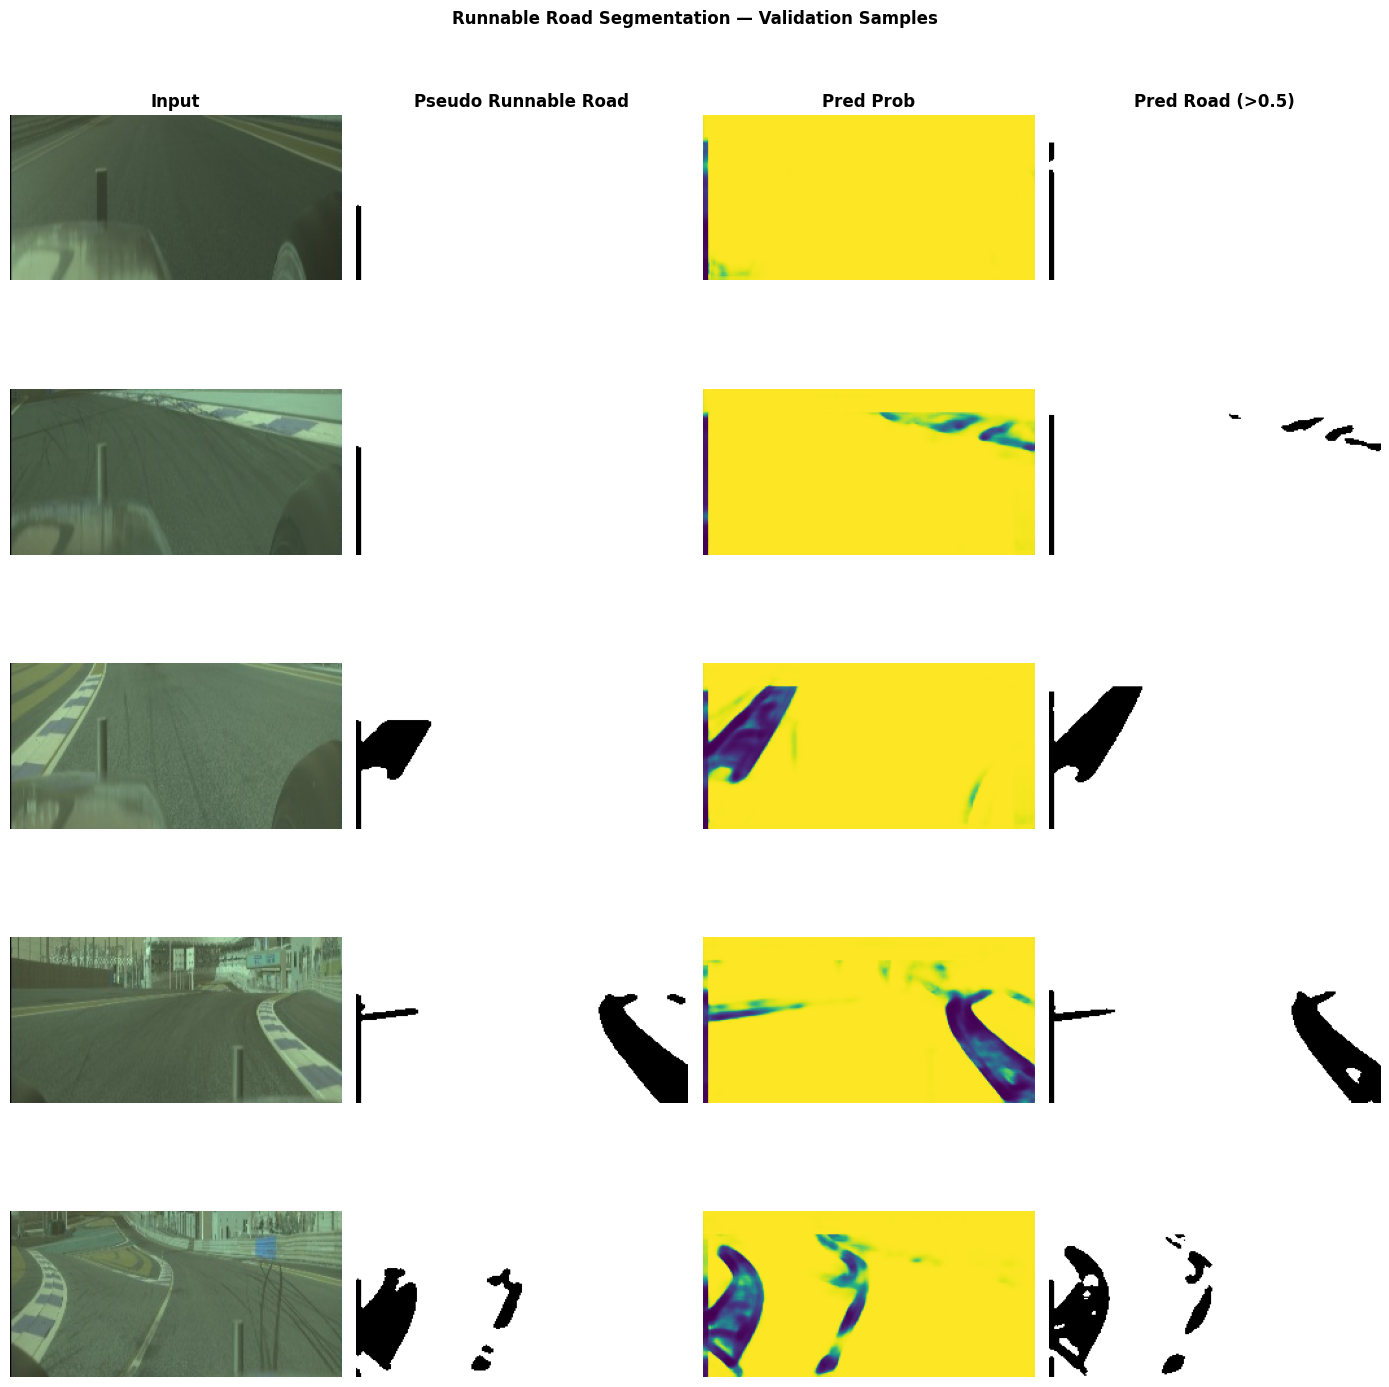

In [15]:
# Evaluate runnable-road segmentation
road_prob = road_model.predict(Xr_val, batch_size=BATCH_SIZE, verbose=0)
road_bin = (road_prob > 0.5).astype(np.float32)

road_inter = np.sum(Yr_val * road_bin, axis=(1, 2, 3))
road_union = np.sum(Yr_val, axis=(1, 2, 3)) + np.sum(road_bin, axis=(1, 2, 3)) - road_inter
road_iou = (road_inter + 1e-6) / (road_union + 1e-6)
print(f"Runnable-road IoU: {road_iou.mean():.4f} ± {road_iou.std():.4f}")

n_show = min(5, len(Xr_val))
idxs = np.linspace(0, len(Xr_val) - 1, n_show, dtype=int)
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

titles = ["Input", "Pseudo Runnable Road", "Pred Prob", "Pred Road (>0.5)"]
for c, t in enumerate(titles):
    axes[0, c].set_title(t, fontweight='bold')

for r, idx in enumerate(idxs):
    axes[r, 0].imshow(Xr_val[idx])
    axes[r, 1].imshow(Yr_val[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[r, 2].imshow(road_prob[idx, :, :, 0], cmap='viridis', vmin=0, vmax=1)
    axes[r, 3].imshow(road_bin[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[r, 0].set_ylabel(f"IoU={road_iou[idx]:.2f}", rotation=0, labelpad=35, fontsize=9, va='center')
    for c in range(4):
        axes[r, c].axis('off')

plt.suptitle("Runnable Road Segmentation — Validation Samples", fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Runnable Road Refinement (v2)

Reduce pseudo-label leakage by enforcing road texture constraints and curb-color exclusion before flood-fill.

Refinements:
- Low-gradient asphalt prior (Sobel magnitude threshold in lower ROI)
- Curb exclusion (blue/white/red HSV masks)
- Multi-seed flood fill fallback near bottom-center

In [16]:
# Build improved runnable-road pseudo-labels (v2)
ROAD_MODEL_V2_PATH = "models/runnable_road_baseline_v2.keras"
ROAD_EDGE_THRESH_V2 = 0.40

def build_curb_mask(img_rgb_u8):
    hsv = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2HSV)
    blue = cv2.inRange(hsv, (85, 60, 50), (135, 255, 255))
    red1 = cv2.inRange(hsv, (0, 70, 50), (10, 255, 255))
    red2 = cv2.inRange(hsv, (170, 70, 50), (180, 255, 255))
    white = cv2.inRange(hsv, (0, 0, 150), (180, 80, 255))
    curb = blue | red1 | red2 | white
    curb = cv2.morphologyEx(curb, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1)
    return curb

def edge_to_runnable_road_v2(edge_prob, img_rgb_norm, edge_thresh=ROAD_EDGE_THRESH_V2):
    h, w = edge_prob.shape
    img_rgb_u8 = (img_rgb_norm * 255.0).astype(np.uint8)
    gray = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    gx = cv2.Sobel(blur, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
    grad = cv2.magnitude(gx, gy)

    roi = np.zeros((h, w), dtype=np.uint8)
    roi[int(h * 0.35):, :] = 255

    grad_roi = grad[roi > 0]
    thr = np.percentile(grad_roi, 68) if grad_roi.size > 0 else 18.0
    asphalt = (grad < thr).astype(np.uint8) * 255
    asphalt = cv2.morphologyEx(asphalt, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1)

    edge_bin = (edge_prob > edge_thresh).astype(np.uint8) * 255
    edge_bin = cv2.dilate(edge_bin, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=1)

    curb = build_curb_mask(img_rgb_u8)
    barrier = edge_bin | curb
    barrier = cv2.bitwise_and(barrier, roi)

    traversable = cv2.bitwise_and(asphalt, roi)
    traversable = cv2.bitwise_and(traversable, cv2.bitwise_not(barrier))

    ff = traversable.copy()
    ff_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    seeds = [(w // 2, h - 2), (int(w * 0.45), h - 2), (int(w * 0.55), h - 2)]
    for sx, sy in seeds:
        if 0 <= sx < w and 0 <= sy < h and ff[sy, sx] > 0:
            cv2.floodFill(ff, ff_mask, seedPoint=(sx, sy), newVal=128)

    road = (ff == 128).astype(np.uint8)
    road = cv2.morphologyEx(road, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1)
    road = cv2.morphologyEx(road, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)), iterations=1)

    # Remove tiny islands
    nlab, lab, stats, _ = cv2.connectedComponentsWithStats(road, connectivity=8)
    cleaned = np.zeros_like(road)
    min_area = int(0.003 * h * w)
    for j in range(1, nlab):
        if stats[j, cv2.CC_STAT_AREA] >= min_area:
            cleaned[lab == j] = 1

    return cleaned.astype(np.float32)

if 'edge_prob_all' not in globals() or edge_prob_all is None or len(edge_prob_all) != len(X):
    edge_prob_all = edge_model.predict(X, batch_size=BATCH_SIZE, verbose=0)

Y_road_v2 = np.zeros((len(X), IMG_H, IMG_W, 1), dtype=np.float32)
for i in range(len(X)):
    Y_road_v2[i, :, :, 0] = edge_to_runnable_road_v2(edge_prob_all[i, :, :, 0], X[i])

Xr2_train, Xr2_val, Yr2_train, Yr2_val = train_test_split(
    X, Y_road_v2, test_size=0.20, random_state=42
 )

print(f"Road v2 pseudo-labels: total {len(X)} | train {len(Xr2_train)} | val {len(Xr2_val)}")
print(f"Road v1 coverage (train/val): {Yr_train.mean()*100:.2f}% / {Yr_val.mean()*100:.2f}%")
print(f"Road v2 coverage (train/val): {Yr2_train.mean()*100:.2f}% / {Yr2_val.mean()*100:.2f}%")

Road v2 pseudo-labels: total 2000 | train 1600 | val 400
Road v1 coverage (train/val): 94.31% / 94.56%
Road v2 coverage (train/val): 20.41% / 20.72%


In [17]:
# Train runnable-road segmentation on v2 pseudo-labels
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + 0.5 * dice_loss(y_true, y_pred)

tf.keras.backend.clear_session()
road_model_v2 = build_road_baseline()
road_model_v2.compile(
    optimizer=keras.optimizers.Adam(6e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric],
)
road_model_v2.summary()

road_callbacks_v2 = [
    ModelCheckpoint(ROAD_MODEL_V2_PATH, monitor='val_iou_metric', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_iou_metric', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

road_history_v2 = road_model_v2.fit(
    Xr2_train, Yr2_train,
    validation_data=(Xr2_val, Yr2_val),
    epochs=14,
    batch_size=BATCH_SIZE,
    callbacks=road_callbacks_v2,
    verbose=1,
 )

road_model_v2 = tf.keras.models.load_model(
    ROAD_MODEL_V2_PATH,
    custom_objects={
        'dice_coefficient': dice_coefficient,
        'iou_metric': iou_metric,
        'dice_loss': dice_loss,
        'bce_dice_loss': bce_dice_loss,
    },
)
print(f"Saved runnable-road v2 model: {ROAD_MODEL_V2_PATH}")

Model: "runnable_road_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 256,  │        672 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 256,  │      5,208 │ conv2d[0][0]      │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 128,   │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 128,   │     10,416 │ max_pooling2d[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 128,   │     20,784 │ conv2d_2[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 64,    │     41,568 │ max_pooling2d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 64,    │     83,040 │ conv2d_4[0][0]    │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 128,   │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 128,   │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 144)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 128,   │     62,256 │ concatenate[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 128,   │     20,784 │ conv2d_6[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 72)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 256,  │     15,576 │ concatenate_1[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 256,  │      5,208 │ conv2d_8[0][0]  

 Total params: 265,537 (1.01 MB)

 Trainable params: 265,537 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/14
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - dice_coefficient: 0.2784 - iou_metric: 0.0219 - loss: 0.8524
Epoch 1: val_iou_metric improved from None to 0.37362, saving model to models/runnable_road_baseline_v2.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - dice_coefficient: 0.3262 - iou_metric: 0.0952 - loss: 0.7739 - val_dice_coefficient: 0.4244 - val_iou_metric: 0.3736 - val_loss: 0.7553 - learning_rate: 6.0000e-04
Epoch 2/14
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - dice_coefficient: 0.4541 - iou_metric: 0.3640 - loss: 0.6443
Epoch 2: val_iou_metric improved from 0.37362 to 0.44970, saving model to models/runnable_road_baseline_v2.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - dice_coefficient: 0.4714 - iou_metric: 0.3750 - loss: 0.6267 - val_dice_coefficient: 0.5162 - val_iou_metric: 0.4497 - val_loss: 0.5809 - learning_rate: 6.0000e-04
Epoch 3/14
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - dice_coefficient: 0.5014 - iou_metric: 0.4237 - loss: 0.5973
Epoch 3: val

Runnable-road v2 IoU (smoothed): 0.6113 ± 0.3015


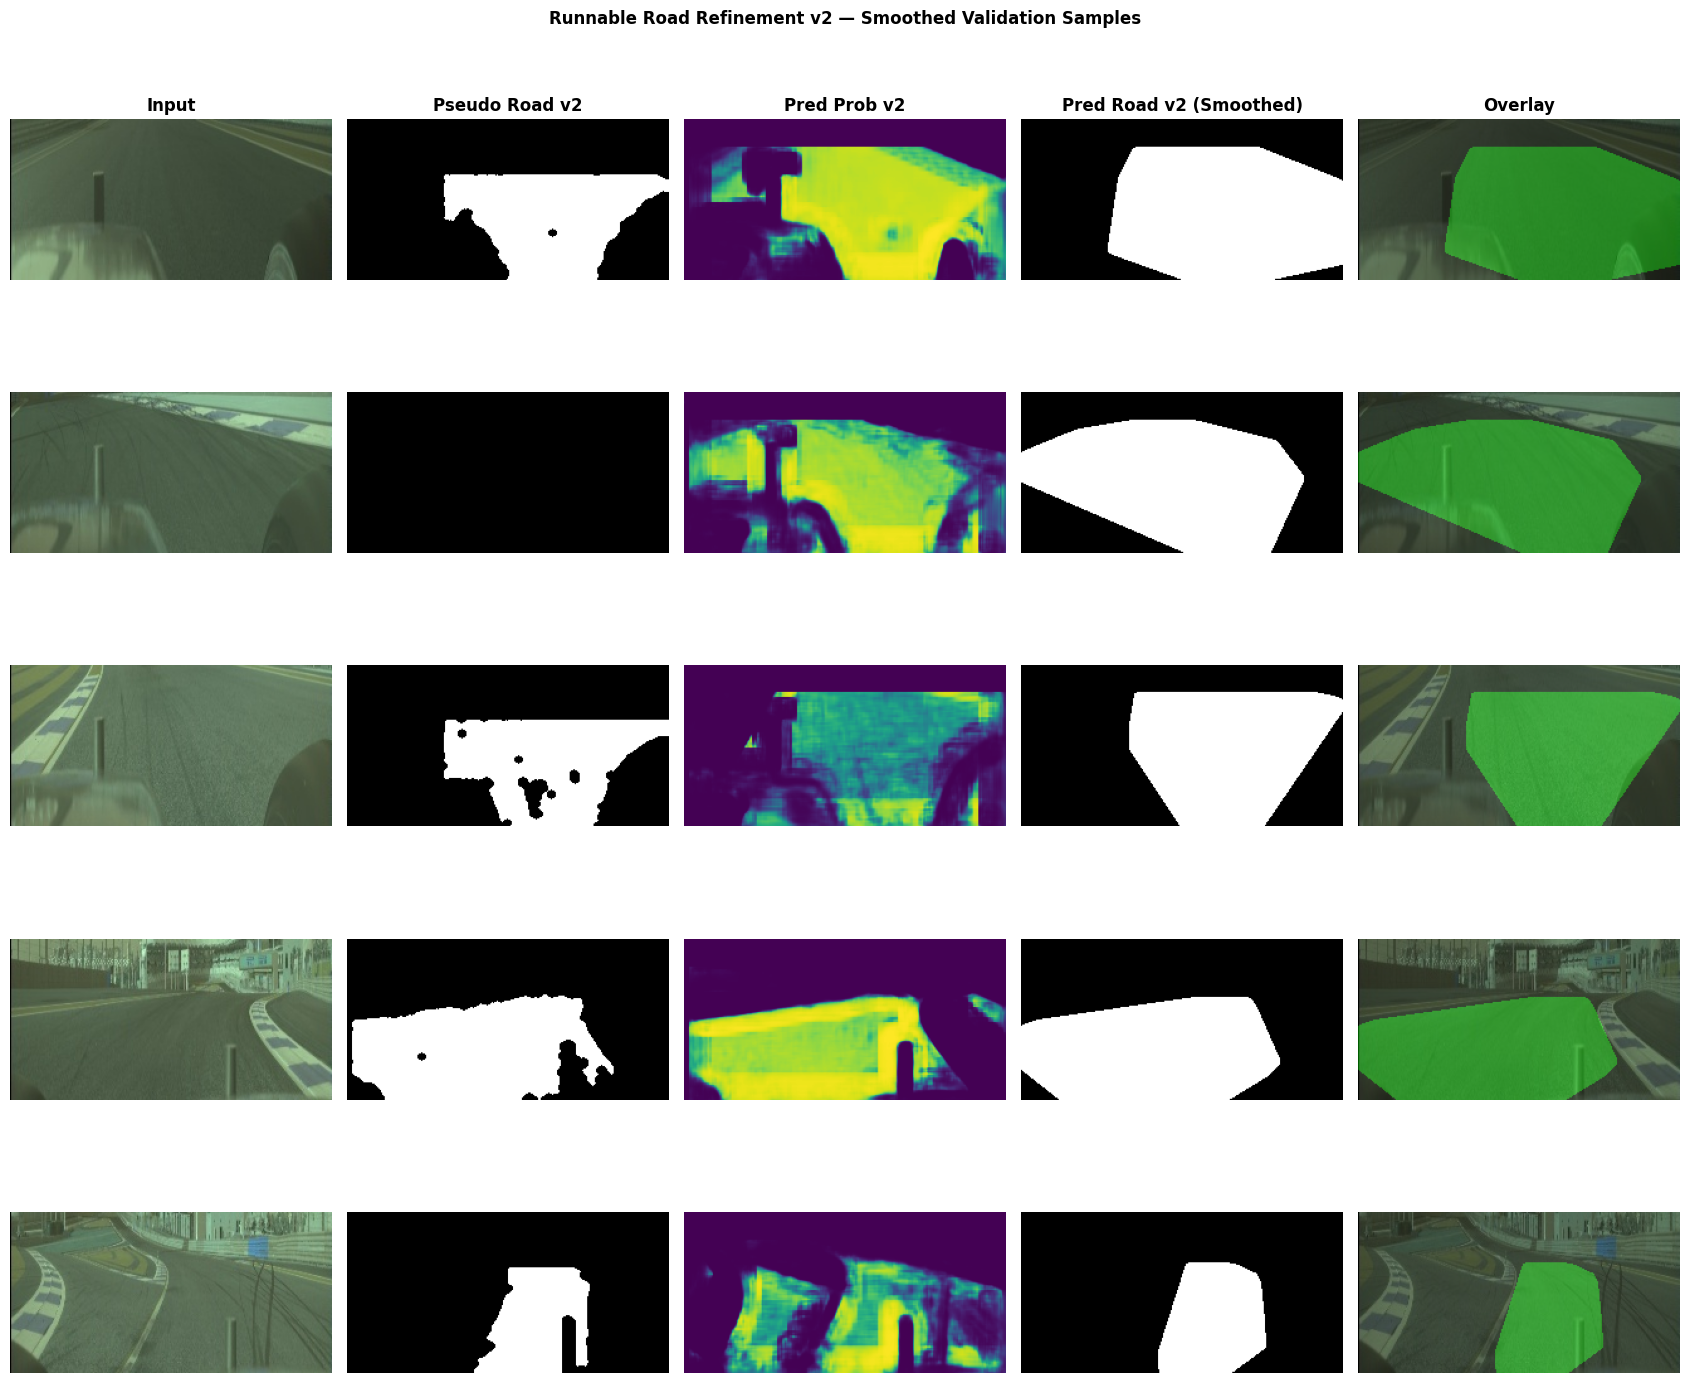

In [20]:
# Evaluate v2 with mask smoothing
road_prob_v2 = road_model_v2.predict(Xr2_val, batch_size=BATCH_SIZE, verbose=0)
road_bin_v2 = (road_prob_v2 > 0.5).astype(np.float32)

def smooth_road_mask(mask_f32):
    m = (mask_f32 > 0.5).astype(np.uint8) * 255
    m = cv2.medianBlur(m, 5)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)), iterations=2)

    # Keep largest connected component
    nlab, lab, stats, _ = cv2.connectedComponentsWithStats((m > 0).astype(np.uint8), connectivity=8)
    if nlab > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        m = np.where(lab == largest, 255, 0).astype(np.uint8)

    # Convex-hull fill to reduce interior holes
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        hull = cv2.convexHull(c)
        m2 = np.zeros_like(m)
        cv2.drawContours(m2, [hull], -1, 255, thickness=cv2.FILLED)
        m = cv2.bitwise_or(m, m2)

    return (m > 0).astype(np.float32)

road_bin_v2_smooth = np.zeros_like(road_bin_v2)
for i in range(len(road_bin_v2)):
    road_bin_v2_smooth[i, :, :, 0] = smooth_road_mask(road_bin_v2[i, :, :, 0])

inter_v2 = np.sum(Yr2_val * road_bin_v2_smooth, axis=(1, 2, 3))
union_v2 = np.sum(Yr2_val, axis=(1, 2, 3)) + np.sum(road_bin_v2_smooth, axis=(1, 2, 3)) - inter_v2
iou_v2 = (inter_v2 + 1e-6) / (union_v2 + 1e-6)
print(f"Runnable-road v2 IoU (smoothed): {iou_v2.mean():.4f} ± {iou_v2.std():.4f}")

n_show = min(5, len(Xr2_val))
idxs = np.linspace(0, len(Xr2_val) - 1, n_show, dtype=int)
fig, axes = plt.subplots(n_show, 5, figsize=(17, 3 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

titles = ["Input", "Pseudo Road v2", "Pred Prob v2", "Pred Road v2 (Smoothed)", "Overlay"]
for c, t in enumerate(titles):
    axes[0, c].set_title(t, fontweight='bold')

for r, idx in enumerate(idxs):
    img = Xr2_val[idx]
    gt = Yr2_val[idx, :, :, 0]
    pr = road_prob_v2[idx, :, :, 0]
    pb = road_bin_v2_smooth[idx, :, :, 0]

    overlay = img.copy()
    green = np.zeros_like(img)
    green[..., 1] = pb
    overlay = np.clip(0.65 * overlay + 0.35 * green, 0, 1)

    axes[r, 0].imshow(img)
    axes[r, 1].imshow(gt, cmap='gray', vmin=0, vmax=1)
    axes[r, 2].imshow(pr, cmap='viridis', vmin=0, vmax=1)
    axes[r, 3].imshow(pb, cmap='gray', vmin=0, vmax=1)
    axes[r, 4].imshow(overlay)
    axes[r, 0].set_ylabel(f"IoU={iou_v2[idx]:.2f}", rotation=0, labelpad=35, fontsize=9, va='center')
    for c in range(5):
        axes[r, c].axis('off')

plt.suptitle("Runnable Road Refinement v2 — Smoothed Validation Samples", fontweight='bold')
plt.tight_layout()
plt.show()